In [1]:
import agrodesign
print(agrodesign)


<module 'agrodesign' from 'D:\\Git Projects\\AGRODESIGN\\agrodesign\\__init__.py'>


In [2]:
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD


In [4]:
import pandas as pd

df = pd.DataFrame({
    "Treatment": ["T1","T1","T2","T2","T3","T3"],
    "Yield": [10,12,15,14,18,17]
})

aov = Anova(df, response="Yield")
aov.crd(treatment="Treatment")


,DF,SS,MS,F,p-value
C(Treatment),2.0,42.333333,21.166667,21.166667,0.017024
Residual,3.0,3.000000,1.000000,NaN,NaN


In [6]:
aov.means(treatment="Treatment")
lsd = LSD(aov)
lsd.test()

,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,b


In [1]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD

df = pd.DataFrame({
    "Block": ["B1","B1","B1","B2","B2","B2"],
    "Treatment": ["T1","T2","T3","T1","T2","T3"],
    "Yield": [10,14,18,12,15,17]
})

aov = Anova(df, response="Yield")

# RCBD ANOVA
aov.rcbd(treatment="Treatment", block="Block")


,DF,SS,MS,F,p-value
C(Treatment),2.0,42.333333,21.166667,18.142857,0.052239
C(Block),1.0,0.666667,0.666667,0.571429,0.528595
Residual,2.0,2.333333,1.166667,NaN,NaN


In [8]:
# Treatment means
aov.means("Treatment")


,Treatment,Mean,Replications
0,T1,11.0,2
1,T2,14.5,2
2,T3,17.5,2


In [9]:
# LSD test
lsd = LSD(aov)
lsd.test()


,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,a


In [5]:
import pandas as pd
from agrodesign.analysis.anova import Anova

df = pd.DataFrame({
    "A": ["A1","A1","A1","A1","A2","A2","A2","A2"],
    "B": ["B1","B1","B2","B2","B1","B1","B2","B2"],
    "Yield": [10,11,14,15,18,17,20,21]
})

aov = Anova(df, response="Yield")

aov.factorial(factor_a="A", factor_b="B")

,DF,SS,MS,F,p-value
C(A),1.0,84.5,84.5,169.0,0.000202
C(B),1.0,24.5,24.5,49.0,0.002192
C(A):C(B),1.0,0.5,0.5,1.0,0.373901
Residual,4.0,2.0,0.5,NaN,NaN


In [6]:
aov.factorial_means("A")

from agrodesign.mean_separation.lsd import LSD
lsd_A = LSD(aov)
lsd_A.test()


,A,Mean,Replications,Group
0,A2,19.0,4,a
1,A1,12.5,4,b


In [4]:
from agrodesign.analysis.assumptions import Assumptions

assump = Assumptions(aov)

# Normality
assump.shapiro_test()


{'Test': 'Shapiro-Wilk',
 'Statistic': np.float64(0.6646559035934576),
 'p-value': np.float64(0.0008917018985140214),
 'Normal': 'No'}

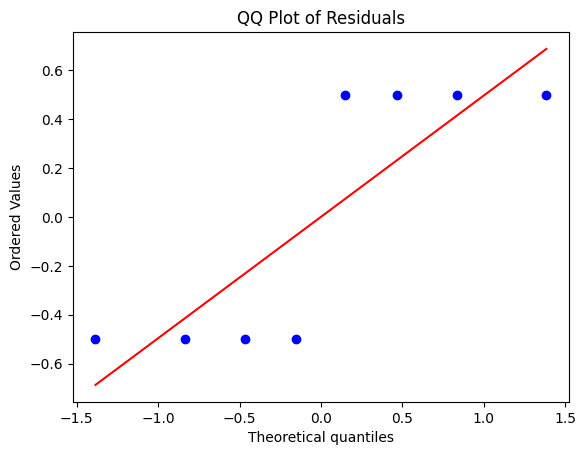

In [4]:
assump.qq_plot()


In [6]:
assump.bartlett_test("A")

{'Test': 'Bartlett',
 'Statistic': np.float64(0.8781123262779806),
 'p-value': np.float64(0.3487192197203338),
 'Homogeneous': 'Yes'}

In [12]:
df

,A,B,Yield
0,A1,B1,10
1,A1,B1,11
2,A1,B2,14
3,A1,B2,15
4,A2,B1,18
5,A2,B1,17
6,A2,B2,20
7,A2,B2,21


In [7]:
from agrodesign.mean_separation.tukey import TukeyHSD

tukey = TukeyHSD(aov, factor="A")
tukey.test()


,A,Mean,Group
0,A2,19.0,a
1,A1,12.5,b


In [8]:
from agrodesign.mean_separation.tukey import TukeyHSD

tukey_A = TukeyHSD(aov, factor=("A","B"))
tukey_A.test()


,A:B,Mean,Group
0,A2:B2,20.5,a
1,A2:B1,17.5,b
2,A1:B2,14.5,c
3,A1:B1,10.5,d


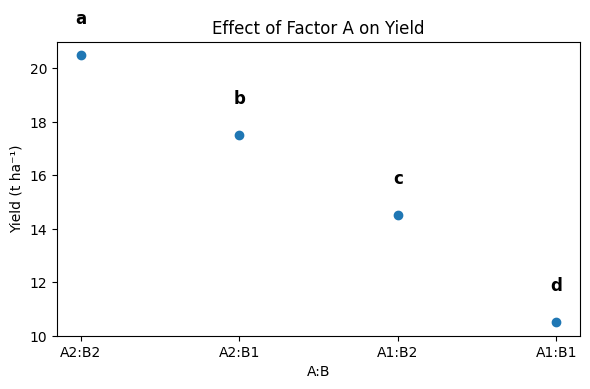

In [9]:
from agrodesign.mean_separation.tukey import TukeyHSD
from agrodesign.plots.mean_plot import mean_plot

tukey_A = TukeyHSD(aov, factor=("A","B"))
means_A = tukey_A.test()

mean_plot(
    means_df=means_A,
    factor="A:B",
    ylabel="Yield (t ha⁻¹)",
    title="Effect of Factor A on Yield",
    kind="point"
)
